In [1]:
import joblib
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OrdinalEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Preprocess data

In [32]:
FEATURES = [
    "duration",
    "orig_bytes",
    "resp_bytes",
    "orig_pkts",
    "resp_pkts",
    "proto",
    "conn_state",
]
def normalize_label_name(label: str) -> str:
    label = str(label).strip()
    return (
        label.replace("-", "_")
             .replace(" ", "_")
             .replace("/", "_")
             .upper()
    )

def preprocess_data(datapath) -> pd.DataFrame:
    df = pd.read_csv(datapath, on_bad_lines="skip", delimiter="\t")
    df.columns = df.columns.str.strip()

    # Remove duplicates and bad numeric values
    df.drop_duplicates(inplace=True)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    df = df[FEATURES + ["label"]].copy()
    df["label"] = df["label"].astype(str).map(normalize_label_name)

    df.dropna(inplace=True)
    return df

In [ ]:
df_cicids2017 = preprocess_data("../data/CICIDS2017/wednesday_labeled.tsv")
df_ciciot2023 = preprocess_data("../data/CICIoT2023/ciciot2023_labeled_conn.tsv")

In [57]:
label_column = "label"

df_cicids2017 = df_cicids2017[df_cicids2017["label"].isin(["DOS_HTTP_FLOOD"] + ["BENIGN"])]
X_cicids = df_cicids2017.drop(columns=[label_column])
y_cicids = df_cicids2017[label_column]

X_ciciot = df_ciciot2023.drop(columns=[label_column])
y_ciciot = df_ciciot2023[label_column]

print("CICIDS test shape:", X_cicids.shape)
print("CICIoT test shape:", X_ciciot.shape)

CICIDS test shape: (497759, 7)
CICIoT test shape: (1850844, 7)


## Load Models

In [61]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    if hasattr(y_true, "cpu"):
        y_true = y_true.cpu().numpy()
    if hasattr(y_pred, "cpu"):
        y_pred = y_pred.cpu().numpy()

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    y_true_str = y_true.astype(str)
    y_pred_str = y_pred.astype(str)

    all_labels = np.unique(np.concatenate([y_true_str, y_pred_str]))

    print(f"\n=== {model_name} Classification Report ===\n")
    print(classification_report(y_true_str, y_pred_str, labels=all_labels, digits=4))

    # Print per-label accuracy
    print(f"\n=== Per-Label Accuracy ===\n")
    for label in all_labels:
        mask = y_true_str == label
        if mask.sum() > 0:
            label_accuracy = (y_pred_str[mask] == label).sum() / mask.sum()
            print(f"{label}: {label_accuracy:.4f}")

    cm = confusion_matrix(y_true_str, y_pred_str, labels=all_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=all_labels, yticklabels=all_labels)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix (counts)")
    plt.tight_layout()
    plt.show()

In [ ]:
def load_and_evaluate_rf_model(joblib_path, X, y_true, model_name):
    joblib_object = joblib.load(joblib_path)
    model = joblib_object["model"]
    encoder = joblib_object.get("encoder")

    # Encode categorical features
    categorical_cols = X.select_dtypes(include=["object"]).columns
    X[categorical_cols] = encoder.transform(X[categorical_cols])
    y_pred = model.predict(X)
    print(f"Evaluation for {model_name}:")
    evaluate_model(y_true, y_pred, model_name=model_name)

C:\Users\Rasmus\AppData\Local\Temp\ipykernel_21724\2191884484.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


Evaluation for CICIDS2017-trained model tested on CICIoT2023:

=== CICIDS2017-trained model tested on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.1849    1.0000    0.3121    342255
DOS_HTTP_FLOOD     1.0000    0.0000    0.0001   1508589

      accuracy                         0.1849   1850844
     macro avg     0.5925    0.5000    0.1561   1850844
  weighted avg     0.8493    0.1849    0.0578   1850844


=== Per-Label Accuracy ===

BENIGN: 1.0000
DOS_HTTP_FLOOD: 0.0000


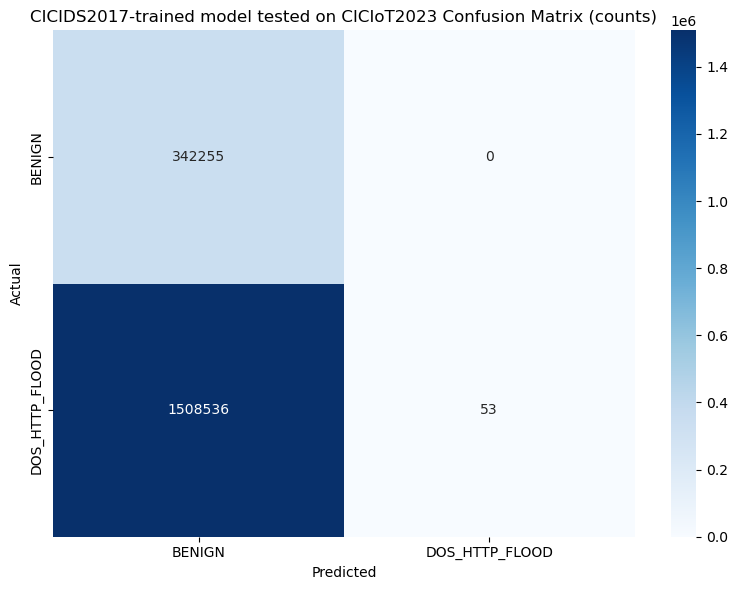

In [ ]:
load_and_evaluate_rf_model(
    "models/random_forest_wednesday_labeled.joblib",
    X=X_ciciot,
    y_true=y_ciciot,
    model_name="CICIDS2017-trained model tested on CICIoT2023"
)

C:\Users\Rasmus\AppData\Local\Temp\ipykernel_21724\2191884484.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


Evaluation for CICIoT2023-trained model tested on CICIDS2017:

=== CICIoT2023-trained model tested on CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.8396    0.8829    0.8608    342990
DOS_HTTP_FLOOD     0.7071    0.6263    0.6643    154769

      accuracy                         0.8031    497759
     macro avg     0.7734    0.7546    0.7625    497759
  weighted avg     0.7984    0.8031    0.7997    497759


=== Per-Label Accuracy ===

BENIGN: 0.8829
DOS_HTTP_FLOOD: 0.6263


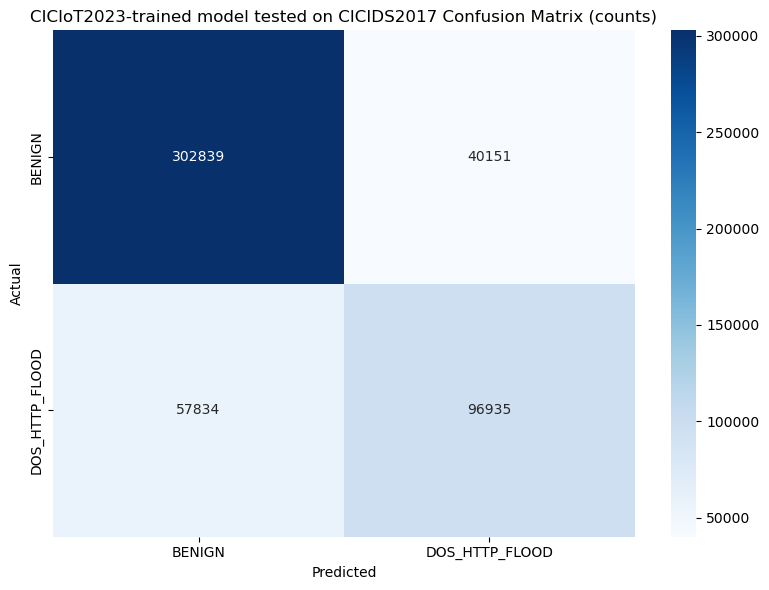

In [ ]:
load_and_evaluate_rf_model(
    "models/random_forest_ciciot2023_labeled_conn.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained model tested on CICIDS2017"
)

In [ ]:
import torch.nn as nn

class CNNLSTM(nn.Module):
    def __init__(self, n_features: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
        )

        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        logits = self.head(last).squeeze(1)
        return logits

In [74]:
def load_and_evaluate_cnnlstm_model(joblib_path, X, y_true, model_name):
    joblib_object = joblib.load(joblib_path)
    model = joblib_object["model"]
    encoder = joblib_object.get("label_encoder")

    # Encode categorical features
    y_pred = model.predict(X)
    print(f"Evaluation for {model_name}:")
    evaluate_model(y_true, y_pred, model_name=model_name)

In [75]:
load_and_evaluate_cnnlstm_model(
    "models/cnnlstm_ciciot2023_labeled_conn.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained model tested on CICIDS2017"
)

AttributeError: 'CNNLSTM' object has no attribute 'predict'